In [1]:
# from Perceptrons import Perceptron
import numpy as np
import matplotlib.pyplot as plt   # for visualization part

In [3]:
import numpy as np
from collections import Counter

class Perceptron:
    def __init__(self, weights, bias=1, learning_rate=0.3):
        """
        'weights' can be a numpy array, list or tuple with the actual values of the weights. The number of input values
        is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.bias = bias
        self.learning_rate = learning_rate

    @staticmethod
    def unit_step_function(x):
        if x <= 0:
            return 0
        else:
            return 1

    def __call__(self, in_data):
        in_data = np.concatenate((in_data, [self.bias]))    # concat the bias value - here it is 1
        # print('in_data', in_data)                         # now it is : [0 0 1]
        result = self.weights @ in_data                     # multiply matrix [ ] [ ]  - same size arrays
        # print('results', result)                            # exercise 1 example :  0.4384837125193516
        return Perceptron.unit_step_function(result)

    def adjust(self, target_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)
        calculated_result = self(in_data)
        # print(calculated_result)
        error = target_result - calculated_result
        if error != 0:
            in_data = np.concatenate((in_data, [self.bias]))
            correction = error * in_data * self.learning_rate
            self.weights += correction

    def evaluate(self, data, labels):
        evaluation = Counter()
        for sample, label in zip(data, labels):
            result = self(sample)  # predict
            if result == label:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation


In [5]:
p = Perceptron(weights=[0.3, 0.3, 0.3],
               bias=1,
               learning_rate=0.2)

In [6]:
def labelled_samples(n):
    for _ in range(n):
        s = np.random.random((2,))
        # print(s)
        yield (s, 1) if s[0] >= 0.5 and s[1] >= 0.5 else (s, 0)


In [8]:
for in_data, label in labelled_samples(30):
    # print(in_data, label)       # [0.86474556 0.47337583] 0
    p.adjust(label, in_data)      # target_result is 1 or 0 which is the label in this case
    

test_data, test_labels = list(zip(*labelled_samples(60)))

evaluation = p.evaluate(test_data, test_labels)
print(evaluation)

Counter({'correct': 51, 'wrong': 9})


In [9]:
"""
The easiest way to see, why it doesn't work, is to visualize the data.
"""
ones = [test_data[i] for i in range(len(test_data)) if test_labels[i] == 1]
# print(ones)           # array([0.61360154, 0.80153096])
zeros = [test_data[i] for i in range(len(test_data)) if test_labels[i] == 0]
# print(zeros)            # array([0.83846534, 0.0988446 ])

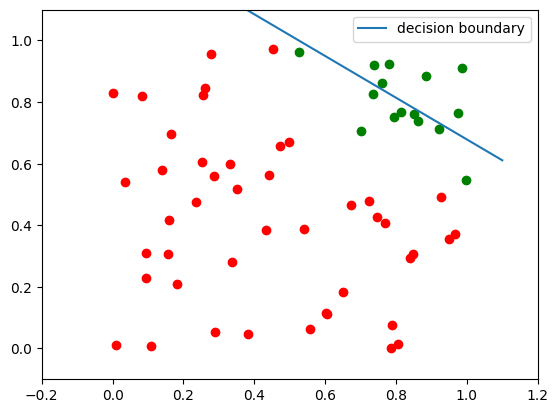

In [14]:
fig, ax = plt.subplots()
xmin, xmax = -0.2, 1.2
X, Y = list(zip(*ones))
# print(X, Y)

ax.scatter(X, Y, color="g")
X, Y = list(zip(*zeros))

ax.scatter(X, Y, color="r")
ax.set_xlim([xmin, xmax])
ax.set_ylim([-0.1, 1.1])

c = -p.weights[2] / p.weights[1]           # bias = 1
m = -p.weights[0] / p.weights[1]
X = np.arange(xmin, xmax, 0.1)

ax.plot(X, m * X + c, label="decision boundary")
plt.legend(loc='upper right')
plt.show()

In [ ]:
"""
We can see that the green points and the red points are not separable by one straight line.
"""